#  PySpark SER Pipeline — Phase 2 : Conv1D Training

**Transition Spark → TensorFlow/Keras** — Entraînement d'un Conv1D

### Étapes du pipeline :
1. **Imports & Configuration**
2. **Chargement Parquet → NumPy** (vérification des 185 dimensions)
3. **Préparation du Tenseur** (StandardScaler, Reshape, One-Hot)
4. **Construction du Conv1D** (256 → 128 → 64 filtres, BatchNorm, Dropout 0.4)
5. **Entraînement avec Callbacks** (ReduceLROnPlateau, EarlyStopping)
6. **Évaluation & Diagnostic** (Courbes Accuracy/Loss, Matrice de Confusion)

### Pré-requis :
- Les fichiers `train_features.parquet` et `test_features.parquet` doivent avoir été générés par la Phase 1
- Vecteur de caractéristiques : **185 dimensions** (MFCC, ZCR, RMS, Spectral, Chroma, Mel, Entropy)

---
## Étape 1 — Imports & Configuration

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, BatchNormalization, MaxPooling1D,
    Flatten, Dense, Dropout, Input
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.utils import to_categorical

# --- Configuration ---
DATASET_PATH = "Dataset/"
DATASET_PATH + "processed"
PARQUET_BASE = DATASET_PATH + "processed"
# PARQUET_BASE = "/content/drive/MyDrive/Colab_Notebooks"
TRAIN_PARQUET = os.path.join(PARQUET_BASE, "train_features.parquet")
TEST_PARQUET  = os.path.join(PARQUET_BASE, "test_features.parquet")

OUTPUT_DIR = "Models/"
MODEL_PATH  = os.path.join(OUTPUT_DIR, "ser_conv1d_model.keras")
CURVES_PATH = os.path.join(OUTPUT_DIR, "training_curves.png")
CM_PATH     = os.path.join(OUTPUT_DIR, "confusion_matrix.png")

print(f"Train path: {TRAIN_PARQUET}")

FEATURE_DIM = 185
BATCH_SIZE  = 64
EPOCHS      = 100
DROPOUT     = 0.4
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f" TensorFlow {tf.__version__}")
print(f"   GPU disponible : {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1774525865.831253  127677 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774525865.832228  127677 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774525865.914082  127677 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774525867.583796  127677 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Train path: Dataset/processed/train_features.parquet
 TensorFlow 2.21.0
   GPU disponible : []


E0000 00:00:1774525868.235011  127677 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774525868.235638  127777 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1774525868.265440  127677 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


---
##  Étape 2 — Chargement Parquet → NumPy

Chargement des fichiers Parquet générés par la Phase 1 (PySpark).
Vérification systématique que **chaque vecteur** fait exactement **185 dimensions**.

In [2]:
# --- Chargement ---
df_train = pd.read_parquet(TRAIN_PARQUET)
df_test  = pd.read_parquet(TEST_PARQUET)

print(f" Train : {len(df_train)} lignes, colonnes = {list(df_train.columns)}")
print(f" Test  : {len(df_test)} lignes,  colonnes = {list(df_test.columns)}")

 Train : 38720 lignes, colonnes = ['path', 'label', 'augmentation', 'features']
 Test  : 2482 lignes,  colonnes = ['path', 'label', 'augmentation', 'features']


In [3]:
# --- Extraction features → NumPy ---
X_train = np.vstack(df_train["features"].values)
X_test  = np.vstack(df_test["features"].values)

y_train_labels = df_train["label"].values
y_test_labels  = df_test["label"].values

# --- Vérification de la taille des vecteurs ---
print(f" Vérification des dimensions :")
print(f"   X_train shape : {X_train.shape}")
print(f"   X_test  shape : {X_test.shape}")

assert X_train.shape[1] == FEATURE_DIM, \
    f" Train: attendu {FEATURE_DIM} features, obtenu {X_train.shape[1]}"
assert X_test.shape[1] == FEATURE_DIM, \
    f" Test: attendu {FEATURE_DIM} features, obtenu {X_test.shape[1]}"

# Vérifier chaque vecteur individuellement
train_lens = np.array([len(f) for f in df_train["features"].values])
test_lens  = np.array([len(f) for f in df_test["features"].values])
assert np.all(train_lens == FEATURE_DIM), \
    f" Vecteurs train incohérents : min={train_lens.min()}, max={train_lens.max()}"
assert np.all(test_lens == FEATURE_DIM), \
    f" Vecteurs test incohérents : min={test_lens.min()}, max={test_lens.max()}"

print(f"    Tous les vecteurs ont exactement {FEATURE_DIM} dimensions")

 Vérification des dimensions :
   X_train shape : (38720, 185)
   X_test  shape : (2482, 185)
    Tous les vecteurs ont exactement 185 dimensions


In [4]:
# --- Distribution des labels ---
print(" Distribution des labels (Train) :")
for label, count in zip(*np.unique(y_train_labels, return_counts=True)):
    print(f"   {label:>10s} : {count}")

print(f"\n Distribution des labels (Test) :")
for label, count in zip(*np.unique(y_test_labels, return_counts=True)):
    print(f"   {label:>10s} : {count}")

# Libérer les DataFrames Pandas
del df_train, df_test

 Distribution des labels (Train) :
        angry : 6100
      disgust : 6184
         fear : 6228
        happy : 6052
      neutral : 5900
          sad : 6192
     surprise : 2064

 Distribution des labels (Test) :
        angry : 398
      disgust : 377
         fear : 366
        happy : 410
      neutral : 420
          sad : 375
     surprise : 136


---
##  Étape 3 — Préparation du Tenseur

| Opération | Détail |
|-----------|--------|
| **StandardScaler** | `fit()` sur le train uniquement, `transform()` sur train + test |
| **Reshape** | `(n, 185)` → `(n, 185, 1)` pour l'entrée Conv1D |
| **One-Hot Encoding** | `LabelEncoder` + `to_categorical()` → 8 classes |

In [5]:
# --- StandardScaler (fit sur train, transform sur les deux) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Vérification post-scaling
assert not np.any(np.isnan(X_train)), " NaN détectés dans X_train après scaling"
assert not np.any(np.isinf(X_train)), " Inf détectés dans X_train après scaling"
assert not np.any(np.isnan(X_test)),  " NaN détectés dans X_test après scaling"
assert not np.any(np.isinf(X_test)),  " Inf détectés dans X_test après scaling"
print(" StandardScaler appliqué — pas de NaN/Inf")

# --- Reshape pour Conv1D : (batch, 185) → (batch, 185, 1) ---
X_train = X_train.reshape(-1, FEATURE_DIM, 1)
X_test  = X_test.reshape(-1, FEATURE_DIM, 1)
print(f" Reshape : X_train={X_train.shape}, X_test={X_test.shape}")

# --- Encodage des labels → One-Hot ---
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_labels)
y_test_enc  = le.transform(y_test_labels)

NUM_CLASSES = len(le.classes_)
y_train = to_categorical(y_train_enc, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_enc,  num_classes=NUM_CLASSES)

print(f" One-Hot Encoding : {NUM_CLASSES} classes → {list(le.classes_)}")
print(f"   y_train shape : {y_train.shape}")
print(f"   y_test  shape : {y_test.shape}")

# Cohérence
assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0]  == y_test.shape[0]

 StandardScaler appliqué — pas de NaN/Inf
 Reshape : X_train=(38720, 185, 1), X_test=(2482, 185, 1)
 One-Hot Encoding : 7 classes → ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
   y_train shape : (38720, 7)
   y_test  shape : (2482, 7)


---
##  Étape 4 — Construction du Conv1D (Architecture Babko-Optimisée)

```
Input: (185, 1)
├── Conv1D(256, kernel=5, relu) + BatchNorm + MaxPool1D(5)
├── Conv1D(128, kernel=5, relu) + BatchNorm + MaxPool1D(5)
├── Conv1D(64,  kernel=5, relu) + BatchNorm + MaxPool1D(5)
├── Flatten
├── Dense(256, relu) + BatchNorm + Dropout(0.4)
├── Dense(128, relu) + BatchNorm + Dropout(0.4)
└── Dense(NUM_CLASSES, softmax)
```

In [6]:
model = Sequential([
    Input(shape=(FEATURE_DIM, 1)),

    # --- Bloc Conv 1 : 256 filtres ---
    Conv1D(256, kernel_size=5, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(pool_size=5),

    # --- Bloc Conv 2 : 128 filtres ---
    Conv1D(128, kernel_size=5, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(pool_size=5),

    # --- Bloc Conv 3 : 64 filtres ---
    Conv1D(64, kernel_size=5, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(pool_size=5),

    # --- Couches denses ---
    Flatten(),

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(DROPOUT),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(DROPOUT),

    Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

# Estimation mémoire
total_params = model.count_params()
mem_mb = (total_params * 4) / (1024 ** 2)
print(f"\n Estimation mémoire modèle : {mem_mb:.1f} MB ({total_params:,} paramètres)")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 185, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 185, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 37, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 37, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 37, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 7, 64)          │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 260,295 (1016.78 KB)

 Trainable params: 258,631 (1010.28 KB)

 Non-trainable params: 1,664 (6.50 KB)


 Estimation mémoire modèle : 1.0 MB (260,295 paramètres)


---
##  Étape 5 — Entraînement avec Callbacks

| Callback | Paramètres |
|----------|------------|
| **ReduceLROnPlateau** | `monitor='val_loss'`, `factor=0.5`, `patience=5`, `min_lr=1e-6` |
| **EarlyStopping** | `monitor='val_loss'`, `patience=10`, `restore_best_weights=True` |

In [7]:
callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
]

print(f" Lancement de l'entraînement")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   Max epochs : {EPOCHS}")
print(f"   Train size : {X_train.shape[0]}, Val size : {X_test.shape[0]}")

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

 Lancement de l'entraînement
   Batch size : 64
   Max epochs : 100
   Train size : 38720, Val size : 2482
Epoch 1/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 35s 52ms/step - accuracy: 0.1583 - loss: 1.9080 - val_accuracy: 0.1475 - val_loss: 1.9075 - learning_rate: 0.0010
Epoch 2/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step - accuracy: 0.1582 - loss: 1.9056 - val_accuracy: 0.1475 - val_loss: 1.9074 - learning_rate: 0.0010
Epoch 3/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 31s 52ms/step - accuracy: 0.1609 - loss: 1.9054 - val_accuracy: 0.1475 - val_loss: 1.9072 - learning_rate: 0.0010
Epoch 4/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 29s 48ms/step - accuracy: 0.1593 - loss: 1.9053 - val_accuracy: 0.1475 - val_loss: 1.9070 - learning_rate: 0.0010
Epoch 5/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 33s 55ms/step - accuracy: 0.1597 - loss: 1.9052 - val_accuracy: 0.1475 - val_loss: 1.9070 - learning_rate: 0.0010
Epoch 6/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.1606 - loss: 1.9052 - val_accuracy: 0.1475 - val_

---
##  Étape 6 — Évaluation & Diagnostic

In [8]:
# --- Score sur le test set ---
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Loss     : {test_loss:.4f}")
print(f" Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")

# --- Classification Report ---
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print(f"\n📋 Classification Report :")
print(classification_report(
    y_true_classes, y_pred_classes,
    target_names=le.classes_,
    digits=3,
))

 Test Loss     : 1.9066
 Test Accuracy : 0.1604 (16.04%)

📋 Classification Report :
              precision    recall  f1-score   support

       angry      0.160     1.000     0.276       398
     disgust      0.000     0.000     0.000       377
        fear      0.000     0.000     0.000       366
       happy      0.000     0.000     0.000       410
     neutral      0.000     0.000     0.000       420
         sad      0.000     0.000     0.000       375
    surprise      0.000     0.000     0.000       136

    accuracy                          0.160      2482
   macro avg      0.023     0.143     0.039      2482
weighted avg      0.026     0.160     0.044      2482



/home/ahroleo/miniconda3/envs/ser_dl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ahroleo/miniconda3/envs/ser_dl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ahroleo/miniconda3/envs/ser_dl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

### Courbes Accuracy / Loss

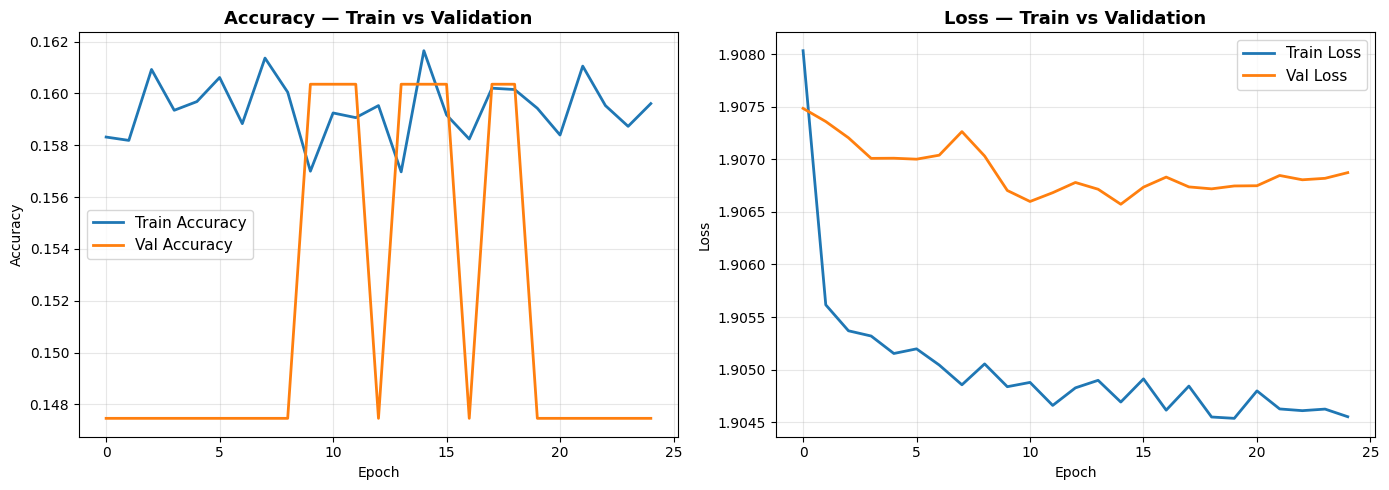

📈 Courbes sauvegardées → Models/training_curves.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history["accuracy"],    label="Train Accuracy", linewidth=2)
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy",   linewidth=2)
axes[0].set_title("Accuracy — Train vs Validation", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history["loss"],     label="Train Loss", linewidth=2)
axes[1].plot(history.history["val_loss"],  label="Val Loss",   linewidth=2)
axes[1].set_title("Loss — Train vs Validation", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CURVES_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"📈 Courbes sauvegardées → {CURVES_PATH}")

###  Matrice de Confusion

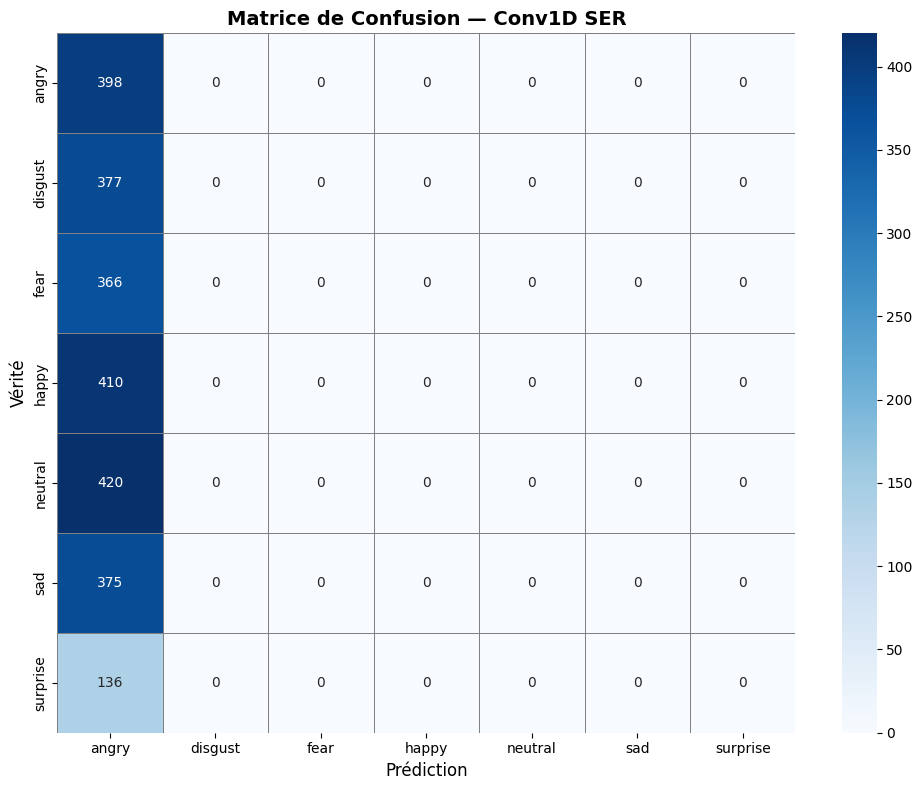

 Matrice de confusion sauvegardée → Models/confusion_matrix.png


In [10]:
cm = confusion_matrix(y_true_classes, y_pred_classes)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax,
    linewidths=0.5,
    linecolor="gray",
)
ax.set_title("Matrice de Confusion — Conv1D SER", fontsize=14, fontweight="bold")
ax.set_xlabel("Prédiction", fontsize=12)
ax.set_ylabel("Vérité", fontsize=12)
plt.tight_layout()
plt.savefig(CM_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f" Matrice de confusion sauvegardée → {CM_PATH}")

---
##  Sauvegarde du modèle

In [11]:
model.save(MODEL_PATH)
print(f" Modèle sauvegardé → {MODEL_PATH}")

# --- Résumé final ---
stopped_epoch = len(history.history["loss"])
best_val_loss = min(history.history["val_loss"])
best_val_acc  = max(history.history["val_accuracy"])

print(f"\n{'=' * 50}")
print(f" PIPELINE PHASE 2 TERMINÉE")
print(f"{'=' * 50}")
print(f"   Epochs effectués   : {stopped_epoch}/{EPOCHS}")
print(f"   Meilleur val_loss  : {best_val_loss:.4f}")
print(f"   Meilleur val_acc   : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"   Test accuracy      : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Modèle             : {MODEL_PATH}")
print(f"   Courbes            : {CURVES_PATH}")
print(f"   Matrice confusion  : {CM_PATH}")

 Modèle sauvegardé → Models/ser_conv1d_model.keras

 PIPELINE PHASE 2 TERMINÉE
   Epochs effectués   : 25/100
   Meilleur val_loss  : 1.9066
   Meilleur val_acc   : 0.1604 (16.04%)
   Test accuracy      : 0.1604 (16.04%)
   Modèle             : Models/ser_conv1d_model.keras
   Courbes            : Models/training_curves.png
   Matrice confusion  : Models/confusion_matrix.png
